[*********************100%***********************]  2 of 2 completed


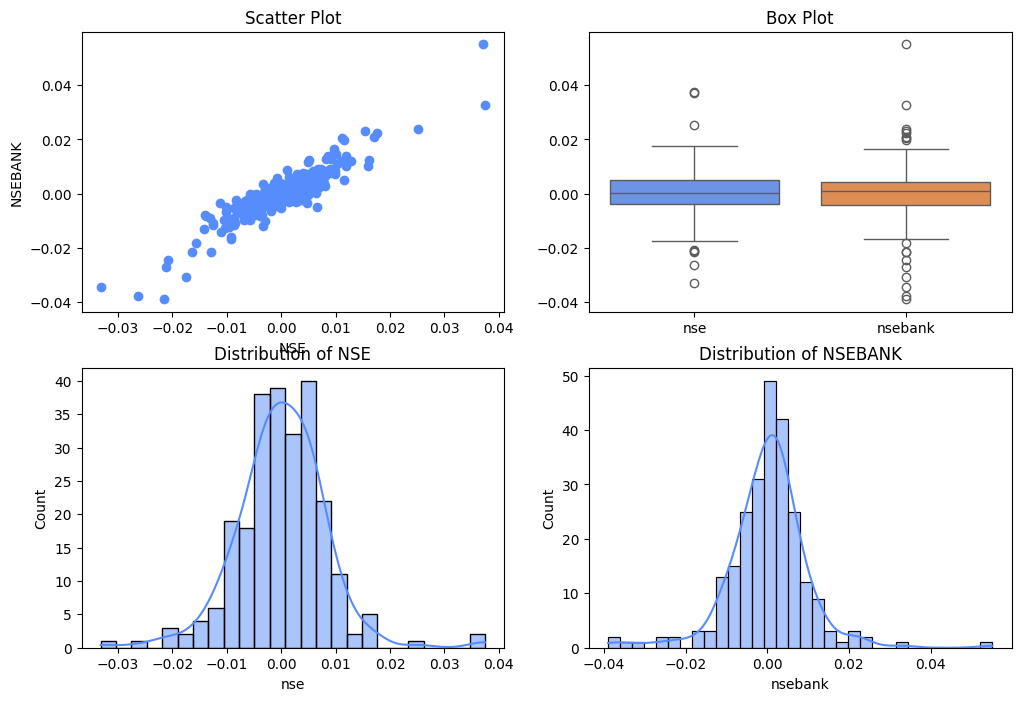

                            OLS Regression Results                            
Dep. Variable:                nsebank   R-squared:                       0.844
Model:                            OLS   Adj. R-squared:                  0.844
Method:                 Least Squares   F-statistic:                     1322.
Date:                Wed, 22 Apr 2026   Prob (F-statistic):          1.72e-100
Time:                        16:42:56   Log-Likelihood:                 1016.3
No. Observations:                 246   AIC:                            -2029.
Df Residuals:                     244   BIC:                            -2022.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       4.983e-05      0.000      0.200      0.8

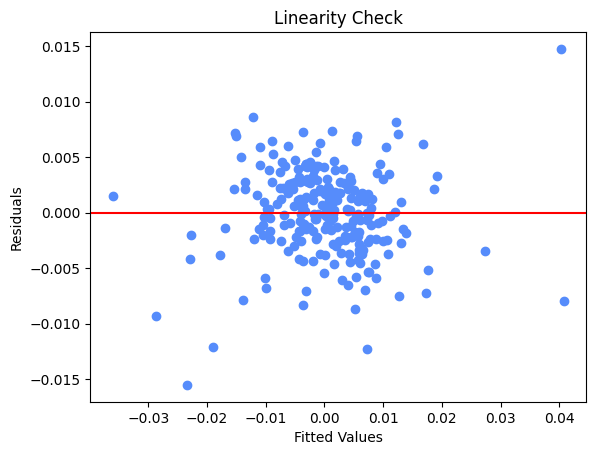

Durbin-Watson: 2.044183234214688


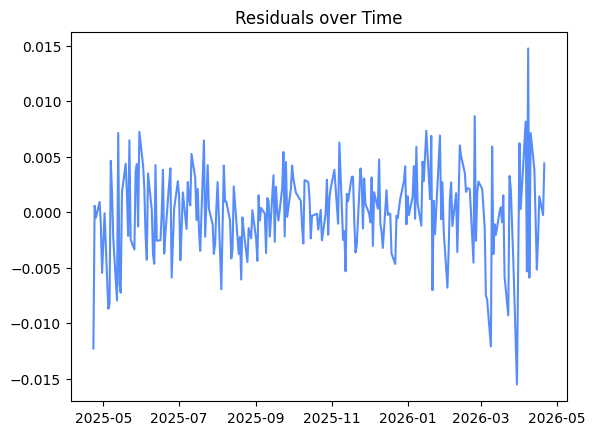

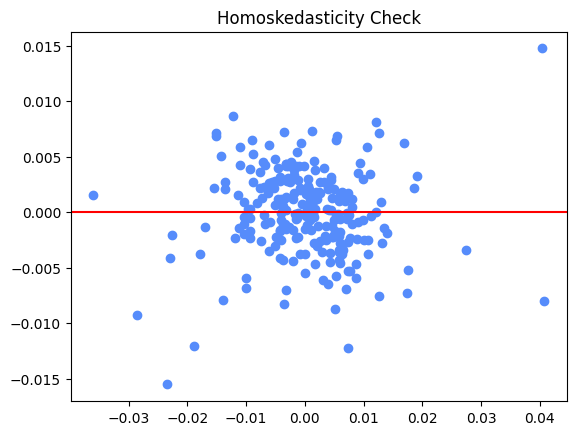

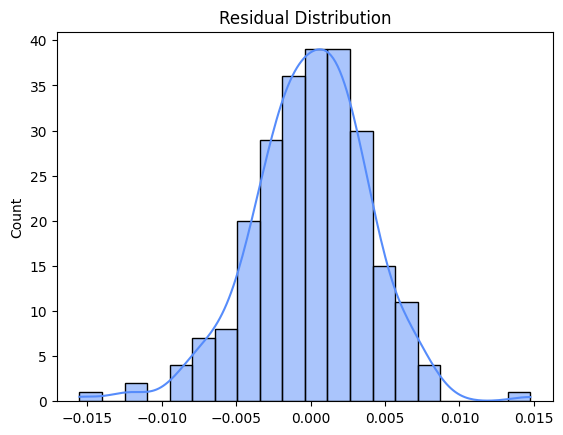

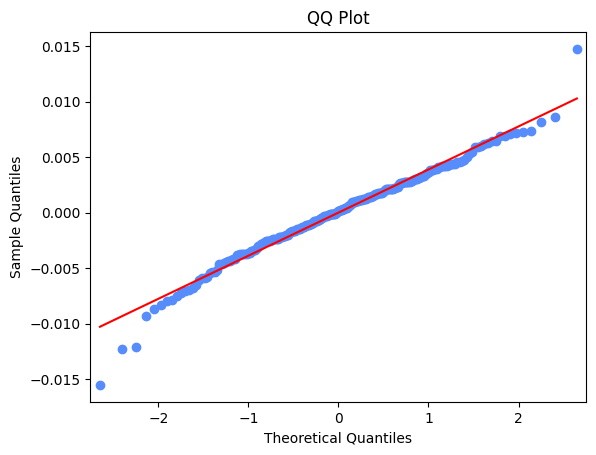

Kurtosis: 1.4982834183432976
Skewness: -0.3339864948761765


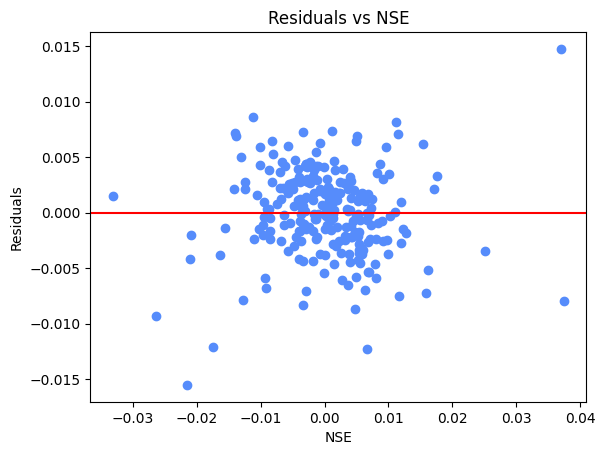

In [1]:
# -------------------------------
# 1. IMPORT LIBRARIES
# -------------------------------

import numpy as np
import pandas as pd

import yfinance as yf
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns

# Statsmodels → statistical regression (detailed output)
import statsmodels.api as sm

# Diagnostics
from statsmodels.stats.stattools import durbin_watson
from scipy.stats import kurtosis, skew


# -------------------------------
# 2. DOWNLOAD DATA
# -------------------------------

# Define time range (last 1 year)
end = dt.date.today()
start = end - dt.timedelta(days=365)

# Download NIFTY and BANK NIFTY prices
df = yf.download(['^NSEI', '^NSEBANK'], start=start, end=end)['Close']


# -------------------------------
# 3. CALCULATE LOG RETURNS
# -------------------------------

# Log return = ln(Pt / Pt-1)
df['nse'] = np.log(df['^NSEI'] / df['^NSEI'].shift(1))
df['nsebank'] = np.log(df['^NSEBANK'] / df['^NSEBANK'].shift(1))

# Remove original price columns (keep only returns)
df.drop(columns=['^NSEI', '^NSEBANK'], inplace=True)

# Drop NaN values created due to shifting
df.dropna(inplace=True)


# -------------------------------
# 4. DEFINE VARIABLES
# -------------------------------

# X = independent variable (NIFTY)
# Y = dependent variable (BANK NIFTY)
x = df['nse']
y = df['nsebank']


# -------------------------------
# 5. BASIC VISUAL ANALYSIS
# -------------------------------

plt.figure(figsize=(12,8))

# Scatter → relationship between variables
plt.subplot(2,2,1)
plt.scatter(x, y)
plt.xlabel('NSE')
plt.ylabel('NSEBANK')
plt.title('Scatter Plot')

# Boxplot → detect outliers
plt.subplot(2,2,2)
sns.boxplot(data=[x, y])
plt.title('Box Plot')

# Distribution of NSE
plt.subplot(2,2,3)
sns.histplot(x, kde=True)
plt.title('Distribution of NSE')

# Distribution of NSEBANK
plt.subplot(2,2,4)
sns.histplot(y, kde=True)
plt.title('Distribution of NSEBANK')

plt.show()


# -------------------------------
# 6. REGRESSION MODEL
# -------------------------------

# Add constant (alpha/intercept)
x_model = sm.add_constant(x)

# Fit regression: NSEBANK = alpha + beta * NSE
model = sm.OLS(y, x_model).fit()

# Full statistical summary
print(model.summary())


# -------------------------------
# 7. RESIDUAL ANALYSIS
# -------------------------------

# Residuals = actual - predicted
residuals = model.resid

# Predicted values
fitted = model.fittedvalues


# -------------------------------
# 8. LINEARITY CHECK
# -------------------------------

# Residuals should be randomly scattered around 0
plt.scatter(fitted, residuals)
plt.axhline(0, color='red')
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Linearity Check")
plt.show()


# -------------------------------
# 9. AUTOCORRELATION CHECK
# -------------------------------

# Durbin-Watson test (ideal ≈ 2)
dw = durbin_watson(residuals)
print("Durbin-Watson:", dw)

# Residuals over time (should look random)
plt.plot(residuals)
plt.title("Residuals over Time")
plt.show()


# -------------------------------
# 10. HOMOSKEDASTICITY CHECK
# -------------------------------

# Variance of residuals should be constant
plt.scatter(fitted, residuals)
plt.axhline(0, color='red')
plt.title("Homoskedasticity Check")
plt.show()


# -------------------------------
# 11. DISTRIBUTION CHECK
# -------------------------------

# Histogram
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()

# QQ plot → should follow straight line if normal
sm.qqplot(residuals, line='s')
plt.title("QQ Plot")
plt.show()


# -------------------------------
# 12. SHAPE OF DISTRIBUTION
# -------------------------------

# Kurtosis → tail risk
print("Kurtosis:", kurtosis(residuals))

# Skewness → asymmetry
print("Skewness:", skew(residuals))


# -------------------------------
# 13. FINAL CHECK (X vs Residuals)
# -------------------------------

# Detect any hidden pattern vs independent variable
plt.scatter(model.model.exog[:,1], model.resid)
plt.axhline(0, color='red')
plt.xlabel("NSE")
plt.ylabel("Residuals")
plt.title("Residuals vs NSE")
plt.show()